# PhysiCar ROS 2

ROS 2 interfaces and the Web API of the PhysiCar robot — same layout as the physicar-ros README.

## [1] ROS 2 Interfaces

### 1.0. Setup

One node shared by every example in this notebook. Re-running is safe — `rclpy.init()` runs only once per kernel.

In [1]:
import json
import math
import time

import requests

import rclpy
from rclpy.qos import qos_profile_sensor_data
from rclpy.wait_for_message import wait_for_message
from IPython.display import Image, display
from geometry_msgs.msg import Twist
from nav_msgs.msg import Odometry
from sensor_msgs.msg import BatteryState, CompressedImage, Imu, LaserScan
from std_msgs.msg import Float64

rclpy.init()

node = rclpy.create_node("tutorial")

BASE_URL = "http://localhost"

### 1.1. Sensors

`wait_for_message` receives a single message without spinning — ideal for notebooks.

#### 1.1.1. Camera

`/camera/image_raw/compressed` · [`CompressedImage`](https://docs.ros2.org/latest/api/sensor_msgs/msg/CompressedImage.html)

Camera image (JPEG) — the payload is a ready-to-display JPEG, no decoding needed.

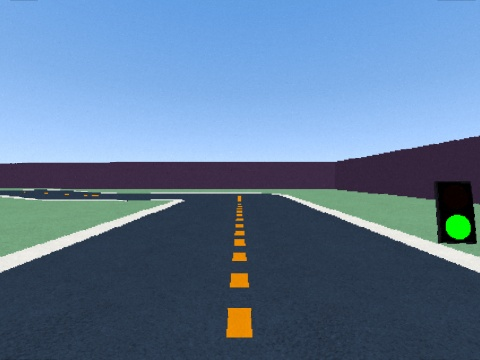

In [2]:
ok, image = wait_for_message(CompressedImage, node, "/camera/image_raw/compressed", time_to_wait=2.0)
display(Image(data=bytes(image.data)))

#### 1.1.2. Battery

`/battery_state` · [`BatteryState`](https://docs.ros2.org/latest/api/sensor_msgs/msg/BatteryState.html)

Battery state (1 Hz). `percentage` is a 0–1 ratio.

In [3]:
ok, battery = wait_for_message(BatteryState, node, "/battery_state", time_to_wait=3.0)
print(f"voltage: {battery.voltage:.2f} V  charge: {battery.percentage:.0%}")

voltage: 8.40 V  charge: 100%


#### 1.1.3. IMU

`/imu` · [`Imu`](https://docs.ros2.org/latest/api/sensor_msgs/msg/Imu.html)

IMU (50 Hz).

In [4]:
ok, imu = wait_for_message(Imu, node, "/imu", time_to_wait=2.0)
av, la = imu.angular_velocity, imu.linear_acceleration
print(f"angular velocity    : x={av.x:.3f}  y={av.y:.3f}  z={av.z:.3f} rad/s")
print(f"linear acceleration : x={la.x:.3f}  y={la.y:.3f}  z={la.z:.3f} m/s^2")

angular velocity    : x=0.000  y=0.000  z=-0.000 rad/s
linear acceleration : x=-0.026  y=0.002  z=9.804 m/s^2


#### 1.1.4. Odometry

`/odom` · [`Odometry`](https://docs.ros2.org/latest/api/nav_msgs/msg/Odometry.html)

Odometry.

In [5]:
ok, odom = wait_for_message(Odometry, node, "/odom", time_to_wait=2.0)
pos, vel = odom.pose.pose.position, odom.twist.twist
print(f"position : x={pos.x:.3f}  y={pos.y:.3f}")
print(f"velocity : linear={vel.linear.x:.3f} m/s  angular={vel.angular.z:.3f} rad/s")

position : x=-5.309  y=4.169
velocity : linear=-0.007 m/s  angular=-0.000 rad/s


#### 1.1.5. LiDAR (raw)

`/scan` · [`LaserScan`](https://docs.ros2.org/latest/api/sensor_msgs/msg/LaserScan.html)

LiDAR scan (raw). LiDAR publishes with best-effort sensor QoS — the subscription must pass `qos_profile_sensor_data` to match.

In [6]:
ok, scan = wait_for_message(LaserScan, node, "/scan",
                            qos_profile=qos_profile_sensor_data, time_to_wait=3.0)
print([round(r, 3) for r in scan.ranges])

[3.582, 3.563, 3.568, 3.566, 3.587, 3.578, 3.571, 3.581, 3.587, 3.56, 3.574, 3.596, 3.585, 3.573, 3.607, 3.602, 3.613, 3.62, 3.612, 3.619, 3.616, 3.614, 3.632, 3.644, 3.636, 3.646, 3.663, 3.671, 3.688, 3.678, 3.708, 3.697, 3.712, 3.713, 3.733, 3.752, 3.756, 3.773, 3.771, 3.791, 3.803, 3.815, 3.807, 3.8, 3.715, 3.66, 3.563, 3.491, 3.444, 3.384, 3.313, 3.256, 3.187, 3.137, 3.085, 3.051, 2.984, 2.913, 2.892, 2.823, 2.782, 2.747, 2.71, 2.67, 2.631, 2.605, 2.558, 2.531, 2.5, 2.465, 2.433, 2.403, 2.365, 2.36, 2.319, 2.291, 2.272, 2.249, 2.219, 2.2, 2.169, 2.153, 2.147, 2.114, 2.09, 2.064, 2.058, 2.02, 2.022, 1.986, 1.975, 1.972, 1.935, 1.922, 1.913, 1.897, 1.886, 1.869, 1.88, 1.838, 1.84, 1.803, 1.815, 1.787, 1.782, 1.773, 1.75, 1.738, 1.72, 1.712, 1.703, 1.683, 1.682, 1.683, 1.698, 1.652, 1.639, 1.65, 1.626, 1.623, 1.641, 1.614, 1.595, 1.596, 1.59, 1.579, 1.58, 1.569, 1.552, 1.546, 1.536, 1.517, 1.536, 1.517, 1.507, 1.522, 1.501, 1.499, 1.505, 1.499, 1.487, 1.484, 1.474, 1.489, 1.463, 1.481

#### 1.1.6. LiDAR (filtered)

`/scan_filtered` · [`LaserScan`](https://docs.ros2.org/latest/api/sensor_msgs/msg/LaserScan.html)

LiDAR scan (filtered).

In [7]:
ok, scan_filtered = wait_for_message(LaserScan, node, "/scan_filtered",
                                     qos_profile=qos_profile_sensor_data, time_to_wait=3.0)
print([round(r, 3) for r in scan_filtered.ranges])

[3.567, 3.574, 3.576, 3.598, 3.567, 3.564, 3.584, 3.594, 3.58, 3.585, 3.578, 3.592, 3.587, 3.607, 3.599, 3.597, 3.608, 3.607, 3.606, 3.628, 3.636, 3.625, 3.643, 3.634, 3.66, 3.646, 3.678, 3.681, 3.681, 3.695, 3.695, 3.711, 3.721, 3.739, 3.735, 3.758, 3.765, 3.785, 3.761, 3.795, 3.819, 3.815, 3.809, 3.806, 3.723, 3.641, 3.579, 3.508, 3.425, 3.387, 3.32, 3.235, 3.204, 3.123, 3.091, 3.031, 2.974, 2.951, 2.877, 2.834, 2.809, 2.741, 2.72, 2.666, 2.643, 2.59, 2.573, 2.525, 2.487, 2.477, 2.435, 2.413, 2.387, 2.374, 2.32, 2.31, 2.269, 2.234, 2.218, 2.206, 2.159, 2.161, 2.123, 2.108, 2.097, 2.072, 2.04, 2.029, 2.015, 2.011, 1.962, 1.953, 1.928, 1.921, 1.925, 1.918, 1.892, 1.88, 1.847, 1.842, 1.836, 1.8, 1.792, 1.785, 1.77, 1.765, 1.751, 1.746, 1.747, 1.728, 1.688, 1.712, 1.691, 1.657, 1.665, 1.677, 1.636, 1.644, 1.629, 1.623, 1.625, 1.598, 1.604, 1.567, 1.578, 1.58, 1.573, 1.541, 1.561, 1.555, 1.553, 1.547, 1.539, 1.519, 1.519, 1.533, 1.486, 1.496, 1.491, 1.504, 1.496, 1.483, 1.469, 1.469, 1.46

### 1.2. Control

Publishing needs a discovered subscriber — each cell waits for the driver before sending (a message published before matching is lost).

#### 1.2.1. Velocity + Steering

`/cmd_vel` · [`Twist`](https://docs.ros2.org/latest/api/geometry_msgs/msg/Twist.html)

Velocity + steering (Ackermann conversion): `linear.x` is speed (m/s), `angular.z` is turn rate (rad/s). Drive commands expire after ~1 s (`cmd_timeout`) without renewal — the speed stops but the wheels keep their angle. A zero `Twist()` is an explicit stop that also recenters the steering.

In [8]:
cmd_vel_pub = node.create_publisher(Twist, "/cmd_vel", 10)
while cmd_vel_pub.get_subscription_count() == 0:
    time.sleep(0.1)

msg = Twist()
msg.linear.x = 0.5
msg.angular.z = 0.5
cmd_vel_pub.publish(msg)

#### 1.2.2. Speed

`/speed` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Speed (m/s) — commands expire after the driver's `cmd_timeout` (default 1 s, `0` disables) without renewal; publish periodically for sustained driving.

In [9]:
speed_pub = node.create_publisher(Float64, "/speed", 10)
while speed_pub.get_subscription_count() == 0:
    time.sleep(0.1)

speed_pub.publish(Float64(data=0.5))

#### 1.2.3. Steering

`/steering` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Steering angle (rad) — + = left, max ±20° (±0.35 rad).

In [10]:
steering_pub = node.create_publisher(Float64, "/steering", 10)
while steering_pub.get_subscription_count() == 0:
    time.sleep(0.1)

steering_pub.publish(Float64(data=math.radians(10)))

#### 1.2.4. Camera Pan

`/camera/pan` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Camera pan (rad) — + = left, range ±30° (±0.52 rad).

In [11]:
pan_pub = node.create_publisher(Float64, "/camera/pan", 10)
while pan_pub.get_subscription_count() == 0:
    time.sleep(0.1)

pan_pub.publish(Float64(data=math.radians(15)))

#### 1.2.5. Camera Tilt

`/camera/tilt` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Camera tilt (rad) — + = up, range ±30° (±0.52 rad).

In [12]:
tilt_pub = node.create_publisher(Float64, "/camera/tilt", 10)
while tilt_pub.get_subscription_count() == 0:
    time.sleep(0.1)

tilt_pub.publish(Float64(data=math.radians(15)))

## [2] Web API

The same interfaces over HTTP — interactive docs at `/docs` (OpenAPI).

### 2.1. Sensor Queries

Query endpoints support real-time streaming via `?stream=true` (camera uses MJPEG, others use SSE).

#### 2.1.1. States

`GET /states` — full state snapshot, select with `?include=odom,battery,imu`.

In [13]:
requests.get(f"{BASE_URL}/states", params={"include": "odom,battery"}).json()

{'cmd': {'speed': 0.0, 'steering': 0.0, 'pan': 0.0, 'tilt': 0.0},
 'odom': {'position': {'x': -5.3094, 'y': 4.1691, 'z': 0.0},
  'orientation': {'yaw': 55.81,
   'quaternion': {'x': 0.0, 'y': 0.0, 'z': 0.468, 'w': 0.8837}},
  'velocity': {'linear': 0.0205, 'angular': 0.0},
  'frame_id': 'odom'},
 'battery': {'voltage': 8.4,
  'percentage': 100.0,
  'current': 0.0,
  'charging': False,
  'present': True},
 'imu': {'acceleration': {'x': 9.8072, 'y': 0.3941, 'z': 9.8066},
  'gyro': {'x': 0.0002, 'y': 0.0, 'z': 0.0975},
  'orientation': {'x': 0.0, 'y': -0.0, 'z': 0.0018, 'w': 1.0}},
 'lidar': {'step': 1.0,
  'count': 360,
  'range_min': 0.1,
  'range_max': 16.0,
  'ranges': {'-180': 3.567,
   '-179': 3.576,
   '-178': 3.567,
   '-177': 3.584,
   '-176': 3.58,
   '-175': 3.578,
   '-174': 3.587,
   '-173': 3.599,
   '-172': 3.608,
   '-171': 3.606,
   '-170': 3.636,
   '-169': 3.643,
   '-168': 3.66,
   '-167': 3.678,
   '-166': 3.681,
   '-165': 3.695,
   '-164': 3.721,
   '-163': 3.735,
 

#### 2.1.2. Speed

`GET /speed` — speed (m/s).

In [14]:
requests.get(f"{BASE_URL}/speed").json()

0.5249

#### 2.1.3. Steering

`GET /steering` — steering angle (rad).

In [15]:
requests.get(f"{BASE_URL}/steering").json()

0.0

#### 2.1.4. Odometry

`GET /odom`

In [16]:
requests.get(f"{BASE_URL}/odom").json()

{'position': {'x': -5.5799, 'y': 4.1369, 'z': 0.0},
 'orientation': {'yaw': 159.94,
  'quaternion': {'x': 0.0, 'y': 0.0, 'z': 0.9847, 'w': 0.1742}},
 'velocity': {'linear': 0.535, 'angular': 0.5075},
 'frame_id': 'odom'}

#### 2.1.5. Battery

`GET /battery`

In [17]:
requests.get(f"{BASE_URL}/battery").json()

{'voltage': 8.4,
 'percentage': 100.0,
 'current': 0.0,
 'charging': False,
 'present': True}

#### 2.1.6. IMU

`GET /imu`

In [18]:
requests.get(f"{BASE_URL}/imu").json()

{'acceleration': {'x': -0.0446, 'y': 0.2514, 'z': 9.8096},
 'gyro': {'x': 0.0001, 'y': -0.0001, 'z': 0.5073},
 'orientation': {'x': 0.0, 'y': -0.0, 'z': 0.1396, 'w': 0.9902}}

#### 2.1.7. LiDAR

`GET /lidar` — scan with `ranges`, `range_min`/`range_max`, `count`.

In [19]:
lidar = requests.get(f"{BASE_URL}/lidar").json()
print(lidar["count"], "points")
print(lidar["ranges"])

360 points
{'-180': 3.984, '-179': 3.991, '-178': 4.02, '-177': 4.036, '-176': 4.068, '-175': 4.074, '-174': 4.059, '-173': 3.881, '-172': 3.744, '-171': 3.561, '-170': 3.447, '-169': 3.313, '-168': 3.209, '-167': 3.105, '-166': 3.003, '-165': 2.904, '-164': 2.816, '-163': 2.717, '-162': 2.669, '-161': 2.577, '-160': 2.51, '-159': 2.472, '-158': 2.409, '-157': 2.357, '-156': 2.312, '-155': 2.268, '-154': 2.223, '-153': 2.17, '-152': 2.121, '-151': 2.087, '-150': 2.056, '-149': 2.008, '-148': 1.981, '-147': 1.957, '-146': 1.928, '-145': 1.898, '-144': 1.877, '-143': 1.849, '-142': 1.842, '-141': 1.804, '-140': 1.765, '-139': 1.728, '-138': 1.742, '-137': 1.71, '-136': 1.673, '-135': 1.679, '-134': 1.658, '-133': 1.625, '-132': 1.624, '-131': 1.614, '-130': 1.599, '-129': 1.582, '-128': 1.587, '-127': 1.565, '-126': 1.548, '-125': 1.539, '-124': 1.53, '-123': 1.542, '-122': 1.518, '-121': 1.49, '-120': 1.495, '-119': 1.489, '-118': 1.489, '-117': 1.481, '-116': 1.492, '-115': 1.47, '-114

#### 2.1.8. Camera

`GET /camera` — camera image (JPEG), resize with `?width`/`?height`.

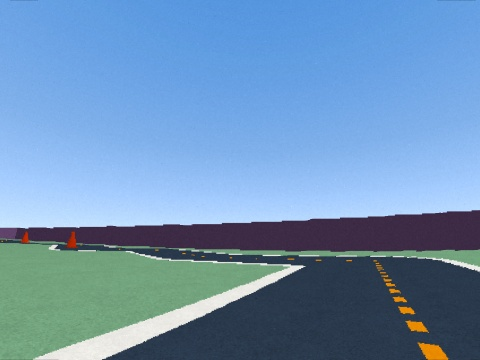

In [20]:
jpg = requests.get(f"{BASE_URL}/camera", params={"width": 480}).content
display(Image(data=jpg))

#### 2.1.9. Camera Pan

`GET /camera/pan` — pan angle (rad).

In [21]:
requests.get(f"{BASE_URL}/camera/pan").json()

0.0

#### 2.1.10. Camera Tilt

`GET /camera/tilt` — tilt angle (rad).

In [22]:
requests.get(f"{BASE_URL}/camera/tilt").json()

0.0

### 2.2. Control

POST the same `{"value": ...}` body everywhere. Speed follows the same `cmd_timeout` contract as the `/speed` topic.

#### 2.2.1. Speed

`POST /speed` — `{"value": m/s, "duration": seconds?}`. Without `duration` it expires after `cmd_timeout` (~1 s) unless renewed. With `duration` the server keeps the command alive, publishes 0 at the end, and the response returns after the drive finishes.

In [23]:
requests.post(f"{BASE_URL}/speed", json={"value": 0.5, "duration": 2.0}, timeout=10).json()

{'success': True, 'value': 0.5, 'message': 'stopped'}

#### 2.2.2. Steering

`POST /steering` — steering angle (rad), persists until changed.

In [24]:
requests.post(f"{BASE_URL}/steering", json={"value": math.radians(10)}).json()

{'success': True, 'value': 0.17453292519943295, 'message': None}

#### 2.2.3. Camera Pan

`POST /camera/pan`

In [25]:
requests.post(f"{BASE_URL}/camera/pan", json={"value": math.radians(15)}).json()

{'success': True, 'value': 0.2617993877991494, 'message': None}

#### 2.2.4. Camera Tilt

`POST /camera/tilt`

In [26]:
requests.post(f"{BASE_URL}/camera/tilt", json={"value": math.radians(15)}).json()

{'success': True, 'value': 0.2617993877991494, 'message': None}

#### 2.2.5. Streaming write (WebSocket)

`WS /speed/stream`, `/steering/stream` — each frame is the same `{"value": x}` as the POST. Dead-man switch: on disconnect the value is zeroed, so a dead client can never leave the robot driving.

In [27]:
from websockets.sync.client import connect

with connect("ws://localhost/speed/stream") as ws:
    for _ in range(20):  # ~2 s of driving at 10 Hz
        ws.send(json.dumps({"value": 0.5}))
        time.sleep(0.1)
# socket closed -> the dead-man switch zeroes the speed

ModuleNotFoundError: No module named 'websockets.sync'

### 2.3. Audio

Command-based playback on the robot speaker (played in the browser viewer in SIM).

#### 2.3.1. Play

`POST /audio/play` — one of `url` / `path` / `data` (base64). Options: `volume` (0–1), `loop`, `replace`.

In [ ]:
import struct
import wave

path = "/tmp/beep.wav"
with wave.open(path, "w") as f:
    f.setnchannels(1)
    f.setsampwidth(2)
    f.setframerate(24000)
    f.writeframes(b"".join(struct.pack("<h", int(8000 * math.sin(2 * math.pi * 440 * t / 24000)))
                           for t in range(24000)))  # 1 s, 440 Hz

requests.post(f"{BASE_URL}/audio/play", json={"path": path, "volume": 0.8}).json()

#### 2.3.2. Now playing

`GET /audio`

In [ ]:
requests.get(f"{BASE_URL}/audio").json()

#### 2.3.3. Stop

`POST /audio/stop` — by `id`, or everything with `{"all": true}`.

In [ ]:
requests.post(f"{BASE_URL}/audio/stop", json={"all": True}).json()